### Carregando Dados

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
X_train = pd.read_parquet('../Datasets/Split/X_train_raw.parquet')
X_test = pd.read_parquet('../Datasets/Split/X_test_raw.parquet')
y_train = pd.read_parquet('../Datasets/Split/y_train.parquet')
y_test = pd.read_parquet('../Datasets/Split/y_test.parquet')

In [3]:
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

### AutoML com AutoGluon

In [6]:
%%capture
from autogluon.tabular import TabularPredictor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
predictor = TabularPredictor(
    label='target',
    problem_type="regression",
    eval_metric="root_mean_squared_error",
    path='./autogluon_models',
).fit(
    train_data=df_train,
    presets="best_quality",
    time_limit=3600,  
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.0
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.4.0: Thu Mar 19 19:33:09 PDT 2026; root:xnu-12377.101.15~1/RELEASE_ARM64_T8112
CPU Count:          8
Pytorch Version:    2.10.0
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       4.51 GB / 16.00 GB (28.2%)
Disk Space Avail:   20.32 GB / 228.27 GB (8.9%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether th

In [10]:
leaderboard = predictor.leaderboard(df_test, silent=True)

In [12]:
leaderboard

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetFastAI_r11_BAG_L1,-0.306155,-0.308251,root_mean_squared_error,0.086557,0.141877,12.311775,0.086557,0.141877,12.311775,1,True,30
1,LightGBMXT_BAG_L1,-0.307066,-0.308669,root_mean_squared_error,0.029064,0.028581,1.265342,0.029064,0.028581,1.265342,1,True,1
2,LightGBM_r30_BAG_L1,-0.307267,-0.308154,root_mean_squared_error,0.053062,0.096073,2.752463,0.053062,0.096073,2.752463,1,True,65
3,LightGBM_r96_BAG_L1,-0.307376,-0.308843,root_mean_squared_error,0.080298,0.083777,1.178655,0.080298,0.083777,1.178655,1,True,15
4,CatBoost_r198_BAG_L1,-0.307400,-0.310048,root_mean_squared_error,0.011256,0.020222,4.290307,0.011256,0.020222,4.290307,1,True,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,NeuralNetTorch_r19_BAG_L1,-0.344434,-0.335972,root_mean_squared_error,0.044187,0.081539,4.503014,0.044187,0.081539,4.503014,1,True,101
103,NeuralNetTorch_r31_BAG_L1,-0.344611,-0.349718,root_mean_squared_error,0.055189,0.110799,8.048687,0.055189,0.110799,8.048687,1,True,61
104,NeuralNetTorch_r121_BAG_L1,-0.349621,-0.342331,root_mean_squared_error,0.061795,0.089209,16.609669,0.061795,0.089209,16.609669,1,True,88
105,NeuralNetTorch_r22_BAG_L1,-0.355114,-0.357583,root_mean_squared_error,0.079126,0.120930,10.634678,0.079126,0.120930,10.634678,1,True,16


In [ ]:
leaderboard.to_csv("../Results/leaderboard_test.csv", index=False)

In [15]:
leaderboard.head(20)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetFastAI_r11_BAG_L1,-0.306155,-0.308251,root_mean_squared_error,0.086557,0.141877,12.311775,0.086557,0.141877,12.311775,1,True,30
1,LightGBMXT_BAG_L1,-0.307066,-0.308669,root_mean_squared_error,0.029064,0.028581,1.265342,0.029064,0.028581,1.265342,1,True,1
2,LightGBM_r30_BAG_L1,-0.307267,-0.308154,root_mean_squared_error,0.053062,0.096073,2.752463,0.053062,0.096073,2.752463,1,True,65
3,LightGBM_r96_BAG_L1,-0.307376,-0.308843,root_mean_squared_error,0.080298,0.083777,1.178655,0.080298,0.083777,1.178655,1,True,15
4,CatBoost_r198_BAG_L1,-0.307400,-0.310048,root_mean_squared_error,0.011256,0.020222,4.290307,0.011256,0.020222,4.290307,1,True,99
5,WeightedEnsemble_L2,-0.307594,-0.302184,root_mean_squared_error,0.309750,0.446326,42.242339,0.001015,0.000169,0.007246,2,True,107
6,LightGBM_r94_BAG_L1,-0.307859,-0.309171,root_mean_squared_error,0.025771,0.049113,1.364755,0.025771,0.049113,1.364755,1,True,57
7,CatBoost_r137_BAG_L1,-0.307932,-0.309509,root_mean_squared_error,0.011620,0.016556,4.001388,0.011620,0.016556,4.001388,1,True,19
8,NeuralNetFastAI_r160_BAG_L1,-0.308348,-0.308393,root_mean_squared_error,0.077202,0.110807,5.894816,0.077202,0.110807,5.894816,1,True,75
9,CatBoost_r50_BAG_L1,-0.308362,-0.309705,root_mean_squared_error,0.014868,0.025346,3.743920,0.014868,0.025346,3.743920,1,True,29


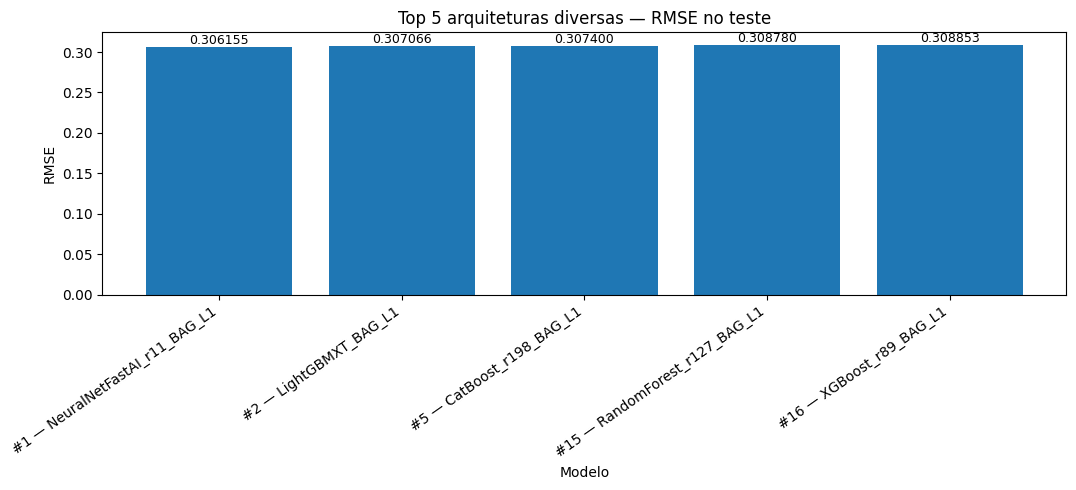

In [14]:
top_diverse = [
    "NeuralNetFastAI_r11_BAG_L1",
    "LightGBMXT_BAG_L1",
    "CatBoost_r198_BAG_L1",
    "RandomForest_r127_BAG_L1",
    "XGBoost_r89_BAG_L1",
]

plot_df = leaderboard.copy()

plot_df["leaderboard_position"] = plot_df.index + 1
plot_df["rmse"] = -plot_df["score_test"]

plot_df = plot_df[plot_df["model"].isin(top_diverse)].copy()

plot_df["model_label"] = plot_df.apply(
    lambda row: f"#{row['leaderboard_position']} — {row['model']}",
    axis=1,
)

plot_df = plot_df.sort_values("rmse", ascending=True)

plt.figure(figsize=(11, 5))

plt.bar(
    plot_df["model_label"],
    plot_df["rmse"],
)

plt.ylabel("RMSE")
plt.xlabel("Modelo")
plt.title("Top 5 arquiteturas diversas — RMSE no teste")

plt.xticks(rotation=35, ha="right")

for i, row in enumerate(plot_df.itertuples()):
    plt.text(
        i,
        row.rmse,
        f"{row.rmse:.6f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

## Model Optimization Pipeline

After identifying the most promising model families through the AutoML stage, a dedicated optimization pipeline was developed to obtain optimized versions of each architecture while maintaining a rigorous evaluation protocol and avoiding data leakage.

### Data Splitting Strategy

Before any model development step, the dataset was divided into independent **training** and **test** sets. The test set was isolated and never used during feature selection, hyperparameter optimization, or model comparison. Its sole purpose was to provide an unbiased estimate of the final model performance.

The following datasets were prepared beforehand:

* **Raw + OHE datasets:** used for tree-based models (LightGBM, CatBoost, Random Forest, and XGBoost);
* **Scaled + OHE datasets:** used for the Neural Network, as neural models typically benefit from standardized inputs.

The same train/test split was maintained throughout the entire optimization process to ensure fair comparisons between model families.

---

### Feature Selection

For each candidate architecture, feature selection was incorporated directly into the optimization pipeline.

A **SelectKBest** approach based on **mutual information regression** was adopted. Mutual information measures the dependency between each feature and the target variable without assuming linear relationships, making it suitable for both linear and non-linear predictive patterns.

Importantly, the number of selected features (**k**) was not fixed beforehand. Instead, it was treated as an additional hyperparameter to be optimized jointly with the model parameters.

Therefore, the optimization process simultaneously searched for:

* the best subset size of features;
* the best hyperparameter configuration for the model itself.

---

### Cross-Validation Procedure

Hyperparameter optimization was performed exclusively using the **training set**.

For each candidate configuration proposed by the optimizer, the following procedure was executed:

1. The training set was divided into **K folds** using K-fold cross-validation.
2. For each fold:

   * Feature selection was fitted using only the current training partition;
   * The selected features were applied to the corresponding validation fold;
   * The model was trained using the selected features from the training partition;
   * Predictions were generated for the validation fold.
3. The validation scores across all folds were aggregated to obtain the average cross-validation performance.

This design ensures that:

> **feature selection never has access to validation data.**

Consequently, the validation estimates more closely reflect the performance expected on unseen data and prevent information leakage.

The optimization objective was the average **Root Mean Squared Error (RMSE)** across folds.

---

### Hyperparameter Optimization

The search process was conducted using **Optuna**, which employs adaptive search strategies to efficiently explore the hyperparameter space.

For each model family, Optuna evaluated multiple combinations of:

* model-specific hyperparameters;
* the number of selected features.

Each trial corresponded to an entire cross-validation cycle as described above.

The objective function minimized:

[
RMSE_{CV}=\frac{1}{K}\sum_{i=1}^{K}RMSE_i
]

where (RMSE_i) denotes the validation RMSE obtained in fold (i).

---

### Final Model Training

After the optimization stage, the best trial was identified according to the lowest cross-validation RMSE.

Using this optimal configuration:

1. Feature selection was fitted once more using the **entire training set**;
2. The final model was trained using all training samples and the selected features;
3. The resulting pipeline was then applied to the untouched **test set**.

Only at this stage was the test set used.

This procedure guarantees that:

> **the test set remains completely independent from model development decisions.**

---

### Final Evaluation

The optimized pipelines were evaluated on the held-out test set using multiple regression metrics:

* **RMSE (Root Mean Squared Error):** primary optimization metric;
* **MAE (Mean Absolute Error):** provides an interpretable measure of average prediction error;
* **R² (Coefficient of Determination):** quantifies the proportion of variance explained by the model.

Predictions generated on the test set were also stored for subsequent analyses.

---

### Artifacts Generated

To ensure reproducibility and facilitate further inspection of the optimization process, the pipeline automatically stores the following outputs for each model family:

* all Optuna trials and tested hyperparameter combinations;
* the cross-validation RMSE associated with each trial;
* the best hyperparameter configuration identified;
* the final optimized pipeline;
* the selected feature subset;
* mutual information scores for all features;
* predictions obtained on the test set;
* a JSON file summarizing the best results;
* a visualization of the **top 10 hyperparameter combinations** ranked by cross-validation RMSE.

Finally, a global summary comparing all optimized architectures is generated, including their cross-validation and test performances.

---

Overall, this workflow provides a robust and reproducible framework for model optimization by jointly selecting informative features and tuning model hyperparameters while strictly separating training, validation, and testing stages to avoid information leakage and obtain reliable estimates of generalization performance.
